## Computational Astrobiology – Project Dataset Inspection

### Preamble – Importing & Reading

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import clear_output

import json
import yaml

import copy
import os
import subprocess
import sys
import time
import re

import tempfile
import h5py

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.stats import median_abs_deviation, skew, kurtosis

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py

from wotan import flatten
from astropy.timeseries import BoxLeastSquares

from matplotlib.ticker import MaxNLocator

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['olivedrab', 'steelblue', 'firebrick', 'goldenrod'])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
#plt.rcParams['axes.formatter.limits'] = (0, 0)
plt.rcParams['figure.figsize'] = [6,4]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

### Auxiliary Functions

In [2]:
# --------------------------------------------------------------- #
# Detrending (Wotan Biweight + Sparse Grid + Failure Protections) #
# --------------------------------------------------------------- #

def detrend(time, flux, flag):

    # --- guard against empty arrays --- #
    
    if len(time) == 0 or len(flux) == 0 or len(flag) == 0:
        return np.array([]), np.array([])

    # --- convert normalized baseline --- #
    
    flux_norm = 1.0 + (flux / 1e6)

    # --- find contiguous blocks using array transitions --- #
    
    good_mask = (flag == 0.0)
    transitions = np.where(np.diff(good_mask.astype(int)) != 0)[0] + 1
    split_indices = np.concatenate(([0], transitions, [len(time)]))

    WINDOW = 3.0
    EDGE = 1/24
    STRIDE = 20

    detrend_chunks = []
    trend_chunks = []

    # --- loop over actual blocks --- #
    
    for lo, hi in zip(split_indices[:-1], split_indices[1:]):
        
        # --- guard against zero width slices --- #
        
        if lo == hi:
            continue
            
        # --- prevent running for flagged blocks --- #
        
        if not good_mask[lo]:
            detrend_chunks.append(np.array([np.nan] * (hi - lo)))
            trend_chunks.append(np.array([np.nan] * (hi - lo)))
            continue
            
        t_chunk = time[lo:hi]
        f_chunk = flux_norm[lo:hi]
        
        # --- additional validation checking degraded chunk structures --- #
        
        if len(t_chunk) == 0:
            continue
            
        chunk_duration = t_chunk[-1] - t_chunk[0]
        
        # --- dynamic parameter protection --- #

        current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
        current_window = WINDOW if chunk_duration > WINDOW else (chunk_duration / 2.0)
        if current_window < 0.1: 
            current_window = 0.1
        
        try:

            # --- stride optimization --- #

            if len(t_chunk) > (STRIDE * 2):
                t_sparse = t_chunk[::STRIDE]
                f_sparse = f_chunk[::STRIDE]
                
                if (len(t_chunk) - 1) % STRIDE != 0:
                    t_sparse = np.append(t_sparse, t_chunk[-1])
                    f_sparse = np.append(f_sparse, f_chunk[-1])
                    
                _, tmp_tr_sparse = flatten(
                    time=t_sparse,
                    flux=f_sparse,
                    method='biweight',
                    window_length=current_window,
                    edge_cutoff=current_edge,
                    return_trend=True
                )
                
                good_trend_mask = np.isfinite(tmp_tr_sparse)
                
                if np.any(good_trend_mask):
                    valid_times = t_sparse[good_trend_mask]
                    t_start, t_end = valid_times[0], valid_times[-1]
                    
                    tmp_tr = np.interp(t_chunk, t_sparse[good_trend_mask], tmp_tr_sparse[good_trend_mask])
                    tmp_tr[(t_chunk < t_start) | (t_chunk > t_end)] = np.nan
                else:
                    tmp_tr = np.full_like(t_chunk, np.nan)
                    
                tmp_detr = f_chunk / tmp_tr

            else:
                
                # --- fallback for very short blocks --- #
                
                tmp_detr, tmp_tr = flatten(
                    time=t_chunk,
                    flux=f_chunk,
                    method='biweight',
                    window_length=current_window,
                    edge_cutoff=current_edge,
                    return_trend=True
                )
        except Exception:
            
            # --- protect execution flow by filling array --- #
            
            tmp_tr = np.full_like(t_chunk, np.nan)
            tmp_detr = np.full_like(t_chunk, np.nan)
        
        detrend_chunks.append(tmp_detr)
        trend_chunks.append(tmp_tr)

    # --- reassemble and return results --- #
    
    full_detrend = np.concatenate(detrend_chunks) if detrend_chunks else np.array([])
    full_trend = np.concatenate(trend_chunks) if trend_chunks else np.array([])
    
    return full_trend, full_detrend

# --------------------------------------------------------- #
# Detection (Astropy Box Least Squares + Crash Protections) #
# --------------------------------------------------------- #

import numpy as np
from astropy.timeseries import BoxLeastSquares

def detect(time, detrend_data):
    if len(time) == 0 or len(detrend_data) == 0:
        return None, None, np.array([])

    # --- strip invalid entries --- #
    
    clean_mask = np.isfinite(time) & np.isfinite(detrend_data)
    if np.sum(clean_mask) < 2:
        return None, None, np.array([])

    tls_time_raw = time[clean_mask]
    tls_flux_raw = detrend_data[clean_mask]

    # --- guard against invalid time range sequencing --- #
    
    if tls_time_raw[-1] <= tls_time_raw[0]:
        return None, None, np.array([])

    # --- fast data binning --- #
    
    bin_size = 0.25 / 24.0 
    bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

    if len(bin_edges) < 2:
        return None, None, np.array([])

    bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
    bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

    valid_bins = bin_counts > 0
    if not np.any(valid_bins):
        return None, None, np.array([])

    binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
    binned_flux = bin_flux[valid_bins] / bin_counts[valid_bins]

    # --- explicit period array --- #
    
    explicit_periods = np.linspace(35.0, 700.0, 10000)
    trial_durations = np.linspace(3.0 / 24.0, 36.0 / 24.0, 5)

    try:
        
        # --- execute transit search within safety wrapper --- #
        
        model = BoxLeastSquares(binned_time, binned_flux)
        results = model.power(
            period=explicit_periods, 
            duration=trial_durations,
            oversample=1
        )

        try:
            peak_indices, _ = find_peaks(results.power, distance=50)
            peak_indices = peak_indices[np.argsort(results.power[peak_indices])][-10:]
        except Exception:
            peak_indices = np.array([])

        return model, results, peak_indices
        
    except Exception:
        return None, None, np.array([])

### Visual Inspection

In [3]:
def visualize(mask, data, seed = 123, smooth = True):
    subset = data[mask]

    row = subset.sample(random_state=seed)
    path, sim = row[['path', 'sim']].iloc[0]
    
    with h5py.File(path, 'r') as f:
        flag = f[f'{sim}/dat/flag'][:]
        flux = f[f'{sim}/dat/flux_var_ppm'][:]
        time = f[f'{sim}/dat/time_s'][:] / (60 * 60 * 24)
        
    if smooth:
        fig, axs = plt.subplots(5, 1, figsize=[7, 20])
        
        trend, detrended = detrend(time, flux, flag)
        clean_mask = np.isfinite(time) & np.isfinite(detrended)
        
        axs[0].plot(time, 0.5 * (trend + detrended), 'k.', mec='none', ms=3, alpha=0.3)
        axs[0].set_xlim(axs[0].set_xlim())
        axs[0].plot([-1e4, 1e4], [1, 1], 'r-', lw=1.8, alpha=0.9)
        axs[0].set_xticks([])
        axs[0].set_ylabel('Flux Variation')
        axs[0].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
        axs[0].set_title('Wotan Biweight Detrended Lightcurve')
        
        axs[1].plot(time, trend, 'k.', mec='none', ms=3, alpha=0.3)
        axs[1].set_xlim(axs[1].set_xlim())
        axs[1].plot([-1e4, 1e4], [1, 1], 'r-', lw=1.8, alpha=0.9)
        axs[1].set_xticks([])
        axs[1].set_ylabel('Flux Variation')
        axs[1].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
        
        axs[2].plot(time, detrended, 'k.', mec='none', ms=3, alpha=0.3)
        axs[2].set_xlim(axs[2].set_xlim())
        axs[2].plot([-1e4, 1e4], [1, 1], 'r-', lw=1.8, alpha=0.9)
        axs[2].set_xlabel('Time / Days')
        axs[2].set_ylabel('Flux Variation')
        axs[2].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
    
        model, results, peaks = detect(time, detrended)

        axs[3].plot(results.period, results.power, 'k-', lw=0.9)
        axs[3].plot(results.period[peaks], results.power[peaks], 'rx', ms=4.5)
        axs[3].set_xlabel('Orbital Period / Days')
        axs[3].set_ylabel('Spectral Power')
        axs[3].set_title('Box Least Squares Analysis')
        axs[3].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))

        peak = peaks[-1]
        best_period = results.period[peak]
        best_initial = results.transit_time[peak]
        best_duration = results.duration[peak]
        best_depth = results.depth[peak] 

        bin_size = 0.25 / 24.0 
        bin_edges = np.arange(time[clean_mask][0], time[clean_mask][-1] + bin_size, bin_size)

        bin_counts, _ = np.histogram(time[clean_mask], bins=bin_edges)
        bin_flux, _ = np.histogram(time[clean_mask], bins=bin_edges, weights=detrended[clean_mask])

        valid_bins = bin_counts > 0
        binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
        binned_flux = bin_flux[valid_bins] / bin_counts[valid_bins]
        
        phase = ((time - best_initial) % best_period) / best_period
        phase[phase > 0.5] -= 1.0

        left, right = np.array([-2, 2]) * best_duration / best_period

        view = (phase >= left) & (phase <= right)

        axs[4].plot(phase[view], detrended[view], 'k.', mec='none', markersize=3, alpha=0.3)

        binned_phase = ((binned_time - best_initial) % best_period) / best_period
        binned_phase[binned_phase > 0.5] -= 1.0

        view = (binned_phase >= left) & (binned_phase <= right)
        
        axs[4].plot(binned_phase[view], binned_flux[view], 'r.', mec='none', markersize=6, alpha=0.9)
        
        axs[4].set_xlabel('Time / Period')
        axs[4].set_ylabel('Flux Variation')

        axs[4].set_title('Phase Folded Transit Window')
        axs[4].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))

        plt.show()
        plt.close()
    else:
        fig, axs = plt.subplots(3, 1, figsize=[7, 12])
        
        flux = 1.0 + (flux / 1e6)
        
        clean_mask = np.isfinite(time) & np.isfinite(flux)
        
        axs[0].plot(time, flux, 'k.', mec='none', ms=3, alpha=0.3)
        axs[0].set_xlim(axs[0].set_xlim())
        axs[0].plot([-1e4, 1e4], [1, 1], 'r-', lw=1.8, alpha=0.9)
        axs[0].set_xlabel('Time / Days')
        axs[0].set_ylabel('Flux Variation')
        axs[0].set_title('Raw Noisy Lightcurve')
        axs[0].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
    
        model, results, peaks = detect(time, flux)

        axs[1].plot(results.period, results.power, 'k-', lw=0.9)
        axs[1].plot(results.period[peaks][5:], results.power[peaks][5:], 'rx', ms=4.5)
        axs[1].set_xlabel('Orbital Period / Days')
        axs[1].set_ylabel('Spectral Power')
        axs[1].set_title('Box Least Squares Analysis')
        axs[1].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))

        peak = peaks[-1]
        best_period = results.period[peak]
        best_initial = results.transit_time[peak]
        best_duration = results.duration[peak]
        best_depth = results.depth[peak] 

        bin_size = 0.25 / 24.0 
        bin_edges = np.arange(time[clean_mask][0], time[clean_mask][-1] + bin_size, bin_size)

        bin_counts, _ = np.histogram(time[clean_mask], bins=bin_edges)
        bin_flux, _ = np.histogram(time[clean_mask], bins=bin_edges, weights=flux[clean_mask])

        valid_bins = bin_counts > 0
        binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
        binned_flux = bin_flux[valid_bins] / bin_counts[valid_bins]
        
        phase = ((time - best_initial) % best_period) / best_period
        phase[phase > 0.5] -= 1.0

        left, right = np.array([-2, 2]) * best_duration / best_period

        view = (phase >= left) & (phase <= right)
        
        axs[2].plot(phase[view], flux[view], 'k.', mec='none', markersize=3, alpha=0.3)

        binned_phase = ((binned_time - best_initial) % best_period) / best_period
        binned_phase[binned_phase > 0.5] -= 1.0

        view = (binned_phase >= left) & (binned_phase <= right)

        axs[2].plot(binned_phase[view], binned_flux[view], 'r.', mec='none', markersize=6, alpha=0.9)
        
        axs[2].set_xlabel('Time / Period')
        axs[2].set_ylabel('Flux Variation')

        axs[2].set_title('Phase Folded Transit Window')
        axs[2].yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
        
        plt.show()
        
    starMag = row['f_mag'].iloc[0]
    starMass = row['f_mass'].iloc[0]
    starTeff = row['f_teff'].iloc[0]

    actSigma = row['t_act_sigma'].iloc[0]
    actTau = row['t_act_tau'].iloc[0]
    actSpot = bool(row['t_act_spot'].iloc[0])
    actFlare = bool(row['t_act_flare'].iloc[0])
    actFlareAmp = row['t_act_flare_amp'].iloc[0] if actFlare else 0.0
    actFlareDur = row['t_act_flare_dur'].iloc[0] if actFlare else 0.0
    actFlarePer = row['t_act_flare_per'].iloc[0] if actFlare else 0.0

    planet = bool(row['t_planet'].iloc[0])
    planetRad = row['t_planet_r'].iloc[0] if planet else 0.0
    planetOrb = row['t_planet_p'].iloc[0] if planet else 0.0
    planetAx = row['t_planet_a'].iloc[0] if planet else 0.0

    scoreB = row['p_B'].iloc[0] if planet else 0.0
    scoreF = row['p_F'].iloc[0] if planet else 0.0
    scoreH = row['p_H'].iloc[0] if planet else 0.0
    scoreR = row['p_R'].iloc[0] if planet else 0.0
    scoreT = row['p_T'].iloc[0] if planet else 0.0
    scoreC = row['p_C'].iloc[0] if planet else 0.0

    outputs = f'''
                                                        === Properties ===
====================================================================================================================================
 Star:       magnitude = {starMag:.2f}   mass = {starMass:.2f}   temperature = {starTeff:.0f}
 ----------------------------------------------------------------------------------------------------------------------------------
 Activity:   sigma = {actSigma:.2f}   tau = {actTau:.2f}
 ----------------------------------------------------------------------------------------------------------------------------------
 Spots:      {actSpot}
 ----------------------------------------------------------------------------------------------------------------------------------
 Flares:     {actFlare}   amplitude = {actFlareAmp:.2f}   period = {actFlarePer:.2f}   duration = {actFlareDur:.2f}
 ----------------------------------------------------------------------------------------------------------------------------------
 Planet:     {planet}   radius = {planetRad:.2f}   period = {planetOrb:.2f}   distance = {planetAx:.2f}
 ----------------------------------------------------------------------------------------------------------------------------------
 Scores:     activity = {scoreH:.3f}   (background = {scoreB:.3f}   flares = {scoreF:.3f})   radius = {scoreR:.3f}   temperature = {scoreT:.3f}   habitability = {scoreC:.3f}
====================================================================================================================================
'''
    print(outputs)

    plt.close()

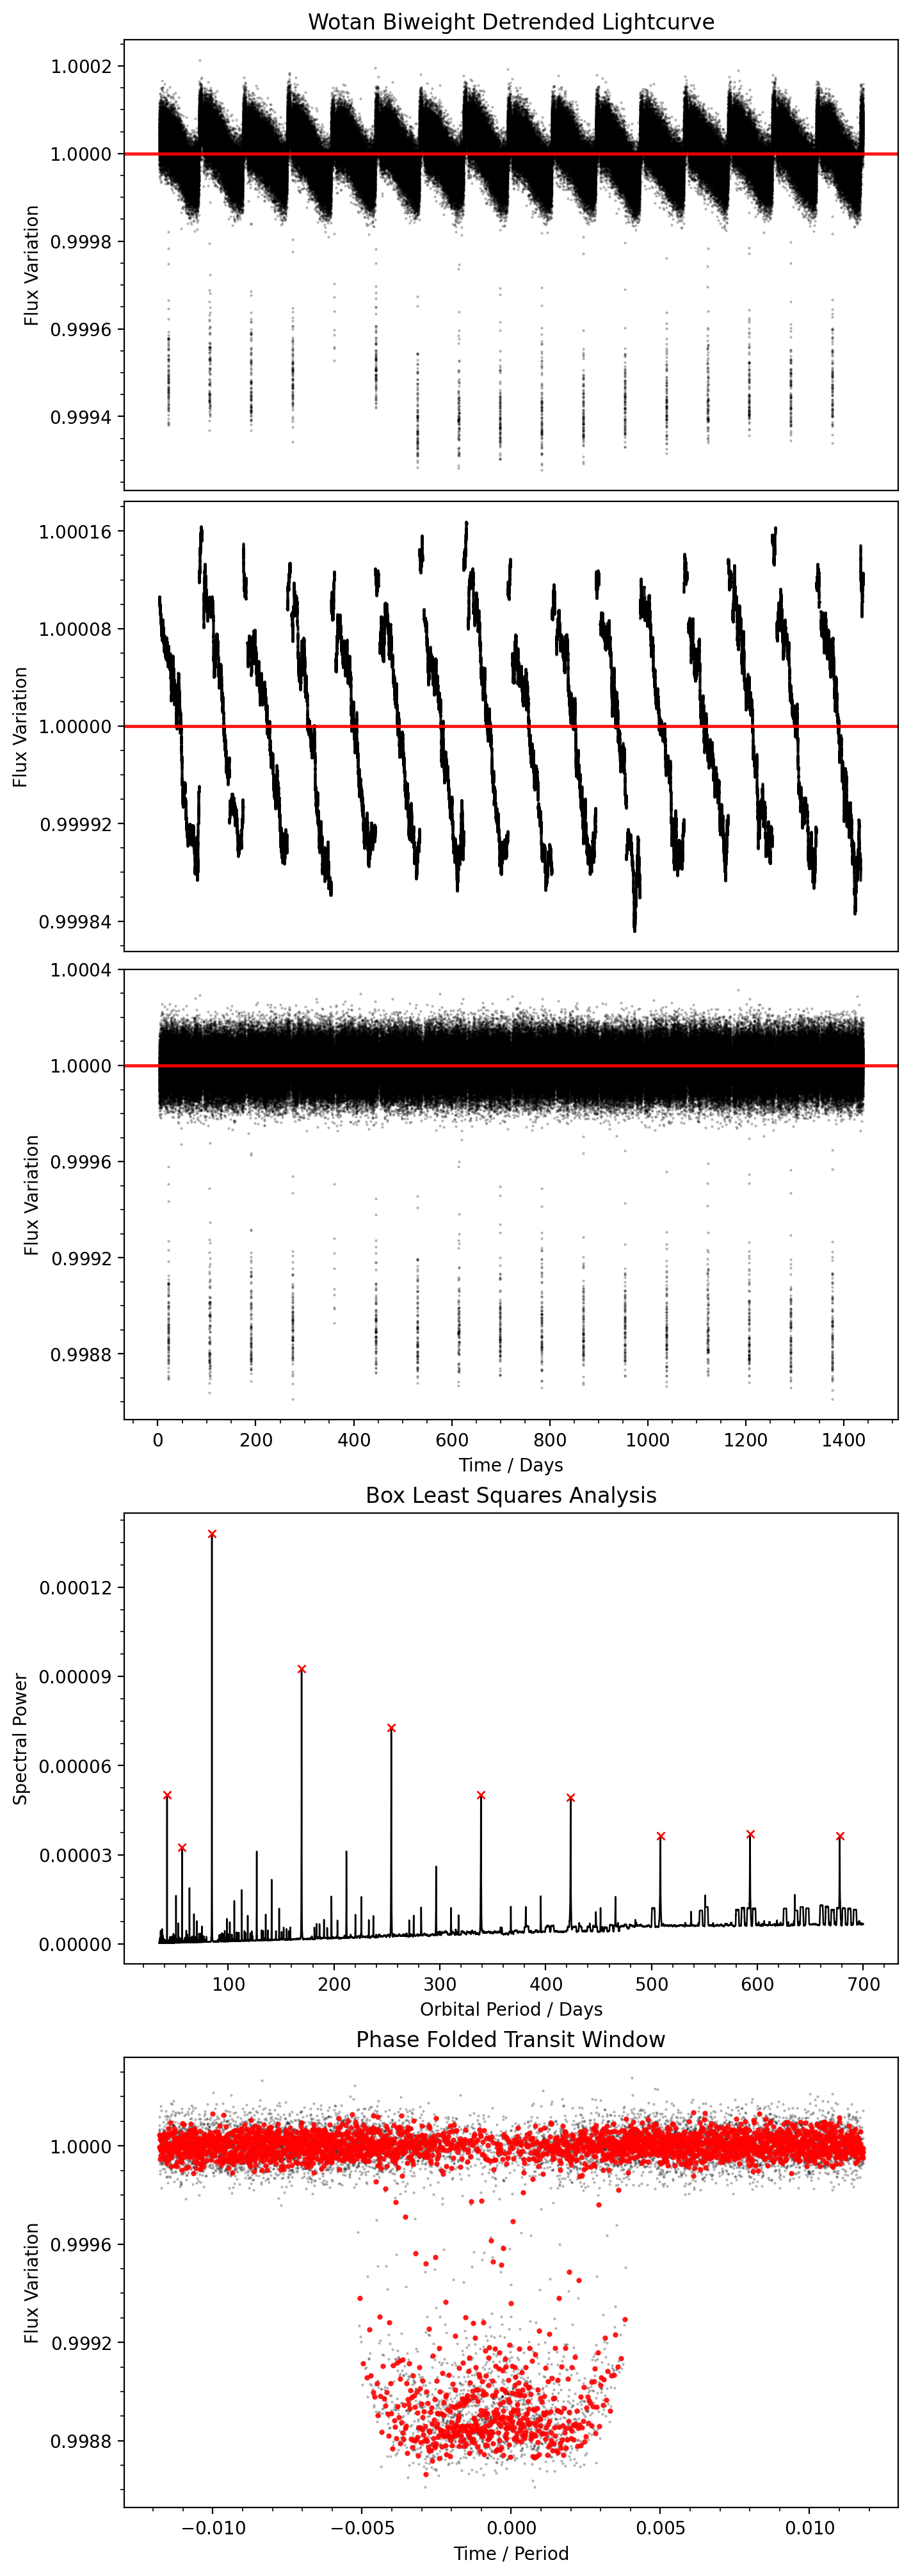


                                                        === Properties ===
 Star:       magnitude = 9.05   mass = 1.10   temperature = 6302
 ----------------------------------------------------------------------------------------------------------------------------------
 Activity:   sigma = 13.19   tau = 19.81
 ----------------------------------------------------------------------------------------------------------------------------------
 Spots:      False
 ----------------------------------------------------------------------------------------------------------------------------------
 Flares:     False   amplitude = 0.00   period = 0.00   duration = 0.00
 ----------------------------------------------------------------------------------------------------------------------------------
 Planet:     True   radius = 3.52   period = 84.72   distance = 0.39
 ---------------------------------------------------------------------------------------------------------------------------------

In [4]:
inputs = ['newTruth', 'newFeatures']

t_df = pd.read_csv(f'{inputs[0]}.csv')
f_df = pd.read_csv(f'{inputs[1]}.csv')
    
df = pd.merge(t_df, f_df, on=['path', 'sim'], how='inner')

visualize((df['t_act_flare'] == 0) & (df['t_act_spot'] == 0) & (df['t_planet'] == 1) & (df['t_planet_r'] > 3.0),
          df, seed = 321, smooth = True)